In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))

from src.metapopulation import Metapopulation
from src.delays import heterogeneous_delay_matrix
from src.delays import uniform_delay_matrix, distance_delay_matrix, heterogeneous_delay_matrix

CONFIG = os.path.join(os.path.dirname(os.path.abspath("__file__")), "distance_delays.yaml")
TOPOLOGIES = ['line', 'full', 'ring', 'lattice']
CONDITIONS = ['distance', 'heterogeneous']

In [2]:
def run(topology, condition):
    model = Metapopulation()
    model.load_config(CONFIG)
    model.create_network(params={'topology': topology})
    if condition == 'distance':
        model.create_delay_matrix(mode='distance', v=1, target_mean_rho=10.0)
    else:
        model.create_delay_matrix(mode='heterogeneous', vm=6.0, p=10, target_mean_rho=10.0, seed=42)
    model.initialise_model()
    model.run_simulation()
    return model

In [3]:
def synchrony_index(trajectories):
    E = trajectories[0]  # (N, T)
    return float(np.mean(np.var(E, axis=0)))


def dominant_frequency(trajectories, dt):
    E = trajectories[0]  # (N, T)
    freqs = np.fft.rfftfreq(E.shape[1], d=dt)
    fft_power = np.abs(np.fft.rfft(E, axis=1))
    fft_power[:, 0] = 0
    fft_mean = np.mean(fft_power, axis=0)
    return float(freqs[np.argmax(fft_mean)])


def mean_delay(delay_matrix):
    N = delay_matrix.shape[0]
    mask = ~np.eye(N, dtype=bool)
    return float(np.mean(delay_matrix[mask]))

In [4]:
results = {}
for topology in TOPOLOGIES:
    for condition in CONDITIONS:
        print(f"Running {topology}, {condition}...")
        m = run(topology, condition)
        D = m.model.params['rho']
        results[(topology, condition)] = {
            'time': m.model.time_array,
            'trajectories': m.model.trajectories,
            'mean_delay': mean_delay(D),
            'synchrony': synchrony_index(m.model.trajectories[:, :, m.model.time_array >= 20]),
            'dom_freq': dominant_frequency(m.model.trajectories[:, :, m.model.time_array >= 20], m.model.dt)
        }
print("All runs complete.")

Running line, distance...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  1.76470588,  3.52941176,  5.29411765,  7.05882353,
         8.82352941, 10.58823529, 12.35294118, 14.11764706, 15.88235294,
        17.64705882, 19.41176471, 21.17647059, 22.94117647, 24.70588235,
        26.47058824],
       [ 1.76470588,  0.        ,  1.76470588,  3.52941176,  5.29411765,
         7.05882353,  8.82352941, 10.58823529, 12.35294118, 14.11764706,
        15.88235294, 17.64705882, 19.41176471, 21.17647059, 22.94117647,
        24.70588235],
       [ 3.52941176,  1.76470588,  0.        ,  1.76470588,  3.52941176,
         5.29411765,  7.05882353,  8.82352941, 10.58823529, 12.35294118,
        14.11764706, 15.88235294, 17.64705882, 19.41176471, 21.17647059,
        22.94117647],
       [ 5.29411765,  3.52941176,  1.76470588,  0.        ,  1.76470588,
         3.52941176,  5.29411765,  7.05882353,  8.8235

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
Running line, heterogeneous...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  1.50534914,  2.62862445, 10.05535613,  6.36568019,
         8.33373631,  7.59075601, 11.36129673, 11.45225937, 13.28149328,
        12.65478459, 19.36399956, 13.74780498, 24.81486379, 19.64889588,
        21.83730882],
       [ 1.50534914,  0.        ,  0.89170249,  3.92773846,  4.10508003,
         6.88011042, 10.94129646,  7.90279247, 17.35548198, 16.55978773,
        14.37359124, 12.68093972, 14.76973668, 18.15223111, 35.87417015,
        27.1060868 ],
       [ 2.62862445,  0.89170249,  0.        ,  1.81356007,  4.44099416,
         9.0338335 ,  6.2956834 ,  6.64889522, 11.15108714,  8.91187736,
        20.61712351, 20.36926755, 15.84078081, 20.98958369, 16.37279777,
        18.67123902],
       [10.05535613,  3.92773846,  1.81356007,  0.        ,  1.86744085,
         5.

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
Running full, distance...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10.

...

Using default integration parameters.
Running lattice, distance...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.  ,  3.75,  7.5 , 11.25,  3.75,  7.5 , 11.25, 15.  ,  7.5 ,
        11.25, 15.  , 18.75, 11.25, 15.  , 18.75, 22.5 ],
       [ 3.75,  0.  ,  3.75,  7.5 ,  7.5 ,  3.75,  7.5 , 11.25, 11.25,
         7.5 , 11.25, 15.  , 15.  , 11.25, 15.  , 18.75],
       [ 7.5 ,  3.75,  0.  ,  3.75, 11.25,  7.5 ,  3.75,  7.5 , 15.  ,
        11.25,  7.5 , 11.25, 18.75, 15.  , 11.25, 15.  ],
       [11.25,  7.5 ,  3.75,  0.  , 15.  , 11.25,  7.5 ,  3.75, 18.75,
        15.  , 11.25,  7.5 , 22.5 , 18.75, 15.  , 11.25],
       [ 3.75,  7.5 , 11.25, 15.  ,  0.  ,  3.75,  7.5 , 11.25,  3.75,
         7.5 , 11.25, 15.  ,  7.5 , 11.25, 15.  , 18.75],
       [ 7.5 ,  3.75,  7.5 , 11.25,  3.75,  0.  ,  3.75,  7.5 ,  7.5 ,
         3.75,  7.5 , 11.25, 11.25,  7.5 , 11.25, 15.  ],
       [11.25,  7.5 ,  3.75,  7.5 ,

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
Running lattice, heterogeneous...
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  3.22063044,  5.62383017, 21.51300659,  3.40477547,
         7.1318697 ,  8.12004975, 13.88972054,  6.12540541,  9.47172991,
        10.82974927, 18.83111505,  7.35321095, 16.33549084, 15.0135631 ,
        18.68799722],
       [ 3.22063044,  0.        ,  1.90775953,  8.40322931,  5.85509604,
         3.67992587,  9.36337529,  8.45384411, 15.91342081,  8.85724031,
        10.25056229, 10.85213238, 11.49062661,  9.70898152, 23.61577249,
        20.71154262],
       [ 5.62383017,  1.90775953,  0.        ,  3.8800346 , 14.25197707,
        12.8850016 ,  3.36733669,  5.69001136, 15.90485097,  8.17139246,
        11.02736462, 14.52639374, 16.94533826, 16.32957135,  8.75722604,
        12.29117582],
       [21.51300659,  8.40322931,  3.8800346 ,  0.        , 15.98124093,
        

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
All runs complete.


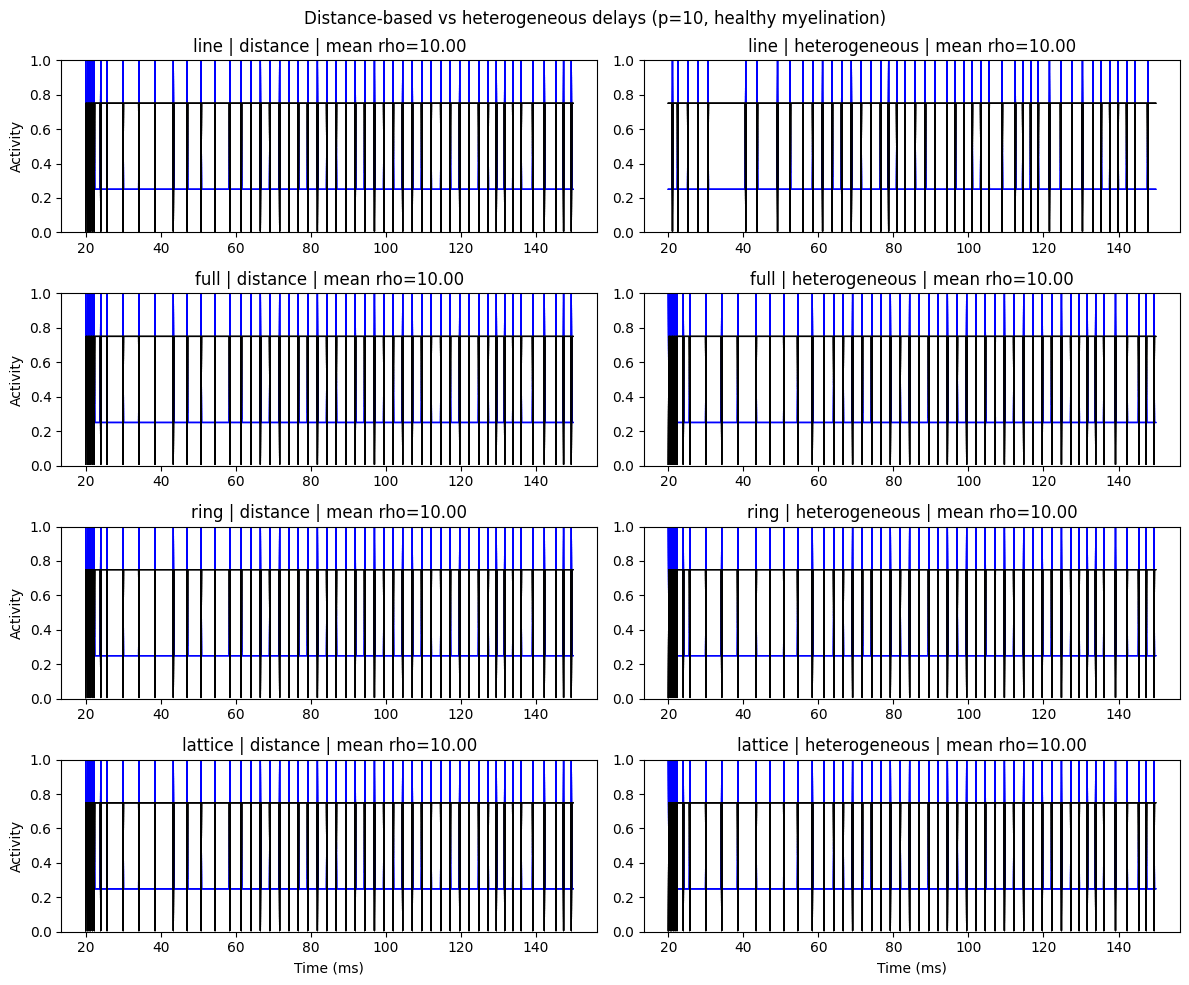

In [5]:
fig, axes = plt.subplots(len(TOPOLOGIES), len(CONDITIONS), figsize=(12, 10))
fig.suptitle("Distance-based vs heterogeneous delays (p=10, healthy myelination)")

for i, topology in enumerate(TOPOLOGIES):
    for j, condition in enumerate(CONDITIONS):
        r = results[(topology, condition)]
        ax = axes[i, j]
        t = r['time']
        mask = t >= 20
        ax.plot(t[mask], r['trajectories'][0][:, mask].T, color='blue', alpha=0.5, linewidth=0.8)
        ax.plot(t[mask], r['trajectories'][1][:, mask].T, color='black', alpha=0.5, linewidth=0.8)
        ax.set_title(f"{topology} | {condition} | mean rho={r['mean_delay']:.2f}")
        ax.set_ylim(0, 1)
        if i == len(TOPOLOGIES) - 1:
            ax.set_xlabel("Time (ms)")
        if j == 0:
            ax.set_ylabel("Activity")

plt.tight_layout()
plt.savefig("kavya_figures/heterogeneous_delays_trajectories.png", dpi=800)
plt.show()

sparse networks (path/line graph) produce irregular, asynchronous dynamics while dense networks (complete graph) maintain stable synchronised limit cycles

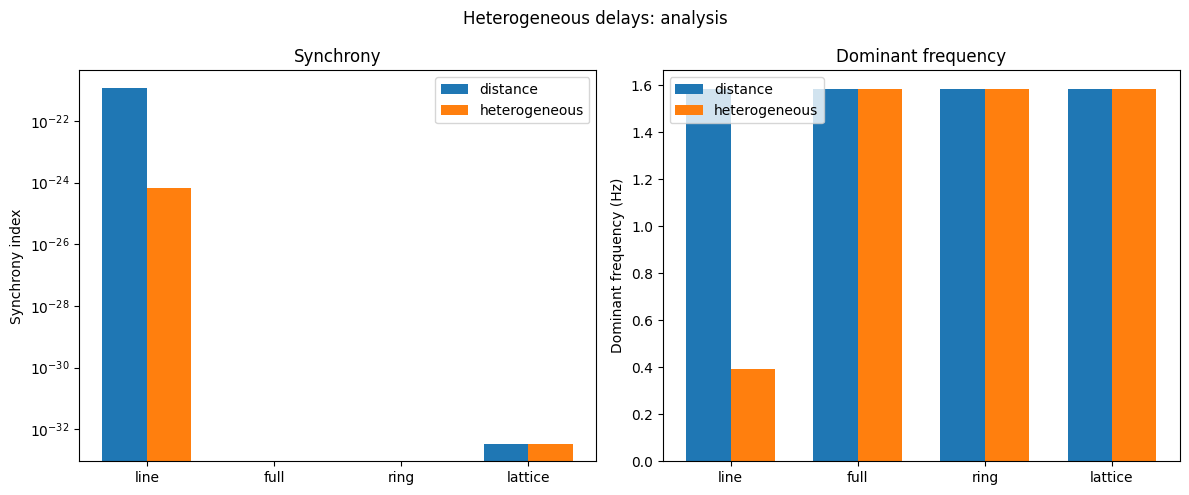

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Heterogeneous delays: analysis")

x = np.arange(len(TOPOLOGIES))
width = 0.35

for k, condition in enumerate(CONDITIONS):
    sync = [results[(t, condition)]['synchrony'] for t in TOPOLOGIES]
    freq = [results[(t, condition)]['dom_freq'] for t in TOPOLOGIES]
    axes[0].bar(x + k*width, sync, width, label=f"{condition}")
    axes[1].bar(x + k*width, freq, width, label=f"{condition}")

axes[0].set_xticks(x + width/2)
axes[0].set_xticklabels(TOPOLOGIES)
axes[0].set_ylabel("Synchrony index")
axes[0].set_title("Synchrony")
axes[0].set_yscale('log')
axes[0].legend()

axes[1].set_xticks(x + width/2)
axes[1].set_xticklabels(TOPOLOGIES)
axes[1].set_ylabel("Dominant frequency (Hz)")
axes[1].set_title("Dominant frequency")
axes[1].legend()

plt.tight_layout()
plt.savefig("kavya_figures/heterogeneous_delays_analysis.png", dpi=800)
plt.show()

In [7]:
print(f"{'Topology':<10} {'p':<6} {'Mean delay':<12} {'Synchrony':<15} {'Dom freq (Hz)':<10}")
print("-" * 55)
for topology in TOPOLOGIES:
    for condition in CONDITIONS:
        r = results[(topology, condition)]
        print(f"{topology:<10} {condition:<15} {r['mean_delay']:<12.3f} {r['synchrony']:<15.3e} {r['dom_freq']:<10.3f}")

Topology   p      Mean delay   Synchrony       Dom freq (Hz)
-------------------------------------------------------
line       distance        10.000       1.172e-21       1.585     
line       heterogeneous   10.000       6.582e-25       0.392     
full       distance        10.000       0.000e+00       1.585     
full       heterogeneous   10.000       0.000e+00       1.585     
ring       distance        10.000       0.000e+00       1.585     
ring       heterogeneous   10.000       0.000e+00       1.585     
lattice    distance        10.000       3.451e-33       1.585     
lattice    heterogeneous   10.000       3.451e-33       1.585     


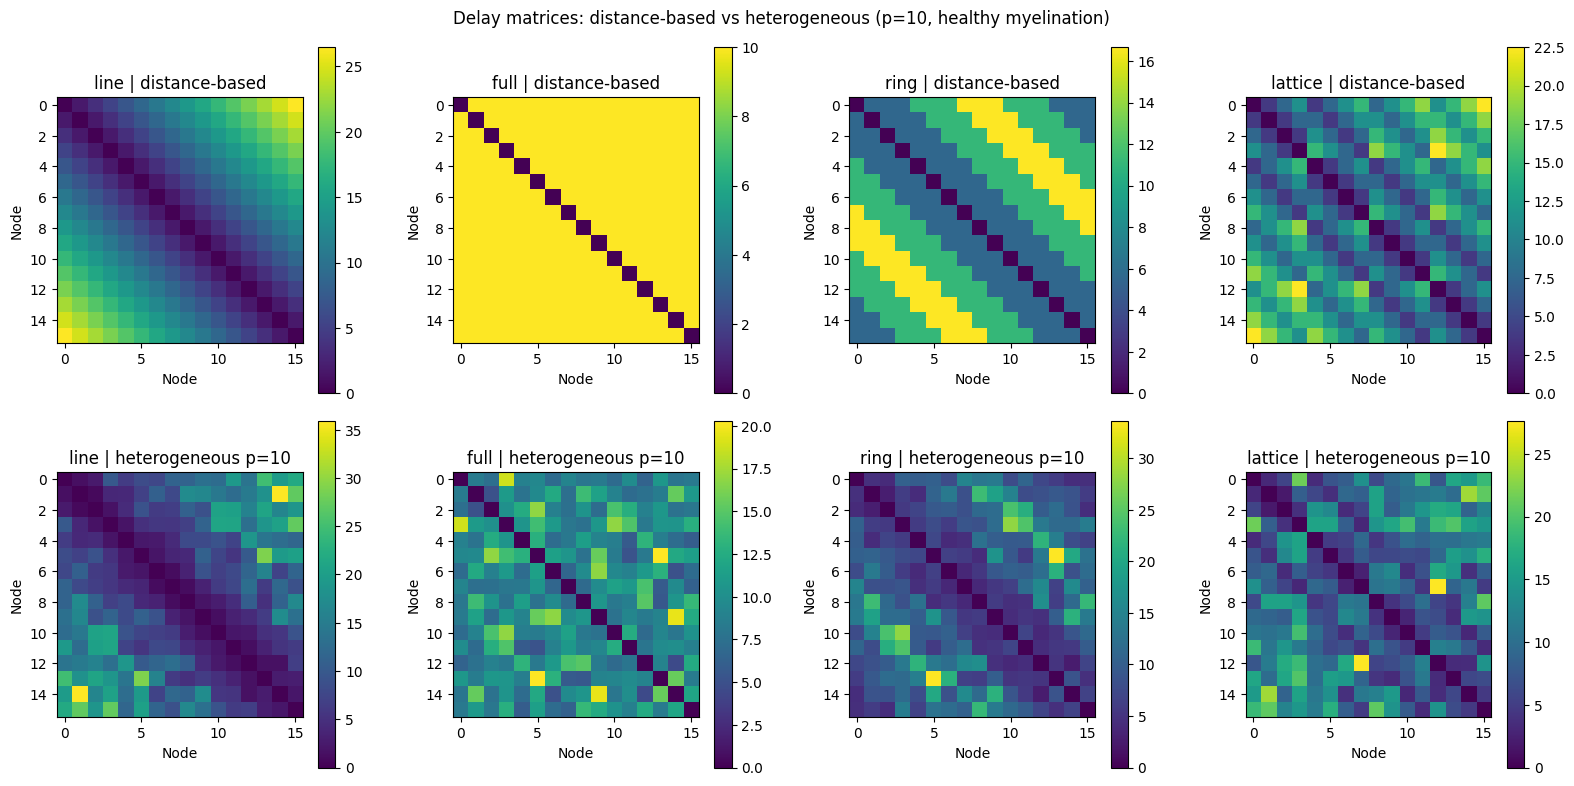

In [8]:
fig, axes = plt.subplots(2, len(TOPOLOGIES), figsize=(16, 8))
fig.suptitle("Delay matrices: distance-based vs heterogeneous (p=10, healthy myelination)")

for i, topology in enumerate(TOPOLOGIES):
    m_temp = Metapopulation()
    m_temp.load_config(CONFIG)
    m_temp.create_network(params={'topology': topology})
    
    D_distance = distance_delay_matrix(m_temp.network, v=1, target_mean_rho=10.0)
    D_hetero = heterogeneous_delay_matrix(m_temp.network, vm=6.0, p=10, target_mean_rho=10.0, seed=42)
    
    im0 = axes[0, i].imshow(D_distance, cmap='viridis')
    axes[0, i].set_title(f"{topology} | distance-based")
    axes[0, i].set_xlabel("Node")
    axes[0, i].set_ylabel("Node")
    plt.colorbar(im0, ax=axes[0, i])
    
    im1 = axes[1, i].imshow(D_hetero, cmap='viridis')
    axes[1, i].set_title(f"{topology} | heterogeneous p=10")
    axes[1, i].set_xlabel("Node")
    axes[1, i].set_ylabel("Node")
    plt.colorbar(im1, ax=axes[1, i])

plt.tight_layout()
plt.savefig("kavya_figures/heterogeneous_delay_matrices.png", dpi=800)
plt.show()

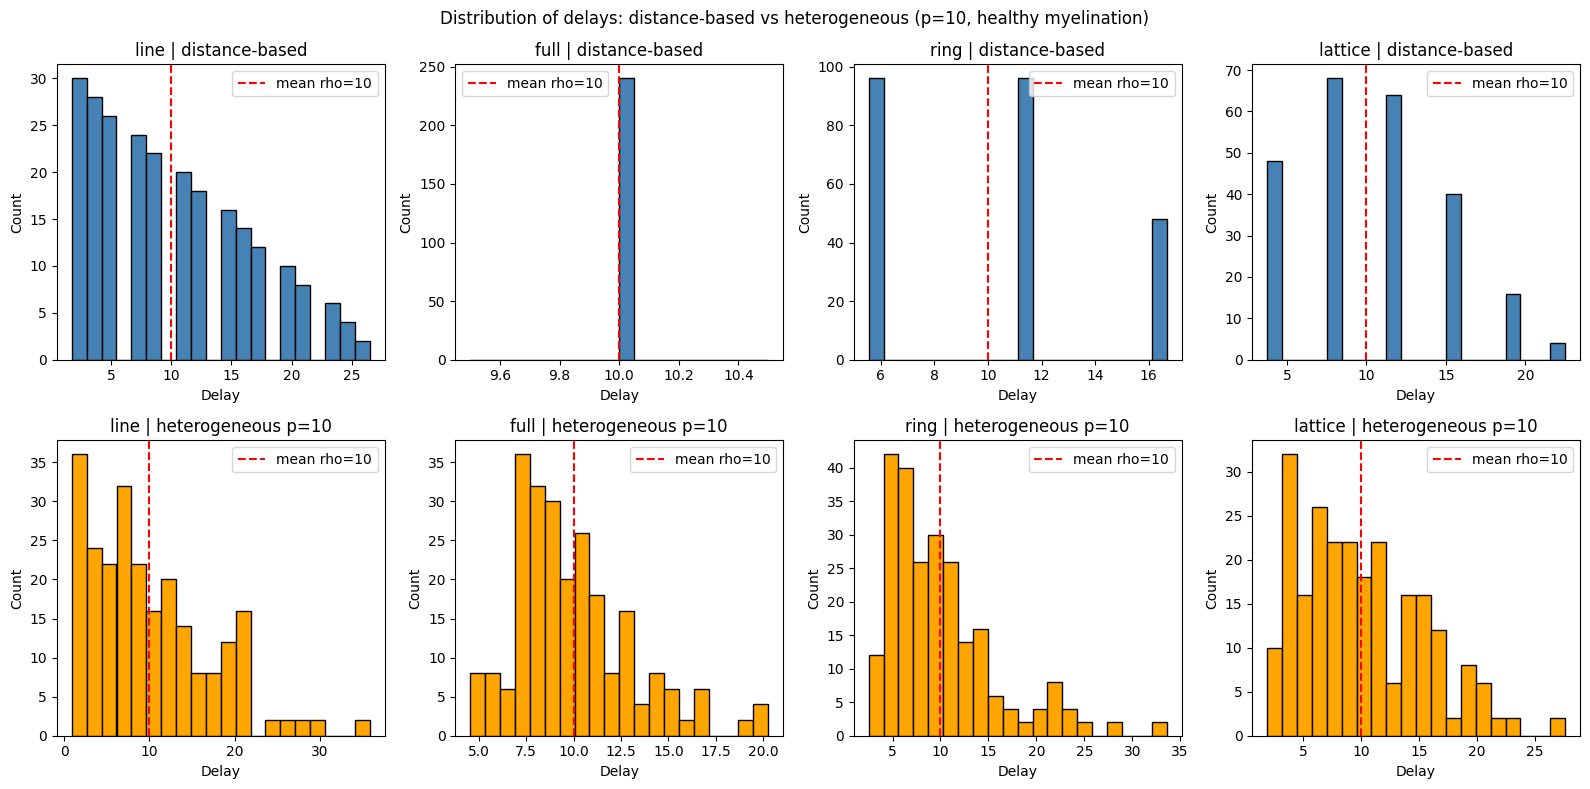

In [9]:
fig, axes = plt.subplots(2, len(TOPOLOGIES), figsize=(16, 8))
fig.suptitle("Distribution of delays: distance-based vs heterogeneous (p=10, healthy myelination)")

for i, topology in enumerate(TOPOLOGIES):
    m_temp = Metapopulation()
    m_temp.load_config(CONFIG)
    m_temp.create_network(params={'topology': topology})
    
    D_distance = distance_delay_matrix(m_temp.network, v=1, target_mean_rho=10.0)
    D_hetero = heterogeneous_delay_matrix(m_temp.network, vm=6.0, p=10, target_mean_rho=10.0, seed=42)
    
    N = m_temp.network.N
    mask = ~np.eye(N, dtype=bool)
    
    axes[0, i].hist(D_distance[mask].flatten(), bins=20, color='steelblue', edgecolor='black')
    axes[0, i].axvline(x=10, color='red', linestyle='--', label='mean rho=10')
    axes[0, i].set_title(f"{topology} | distance-based")
    axes[0, i].set_xlabel("Delay")
    axes[0, i].set_ylabel("Count")
    axes[0, i].legend()
    
    axes[1, i].hist(D_hetero[mask].flatten(), bins=20, color='orange', edgecolor='black')
    axes[1, i].axvline(x=10, color='red', linestyle='--', label='mean rho=10')
    axes[1, i].set_title(f"{topology} | heterogeneous p=10")
    axes[1, i].set_xlabel("Delay")
    axes[1, i].set_ylabel("Count")
    axes[1, i].legend()

plt.tight_layout()
plt.savefig("kavya_figures/heterogeneous_delay_distributions.png", dpi=800)
plt.show()

In [10]:
print(f"{'Topology':<10} {'p':<6} {'Mean delay':<12} {'Synchrony':<15} {'Dom freq (Hz)':<10}")
print("-" * 55)
for topology in TOPOLOGIES:
    for condition in CONDITIONS:
        r = results[(topology, condition)]
        print(f"{topology:<10} {condition:<15} {r['mean_delay']:<12.3f} {r['synchrony']:<15.3e} {r['dom_freq']:<10.3f}")

Topology   p      Mean delay   Synchrony       Dom freq (Hz)
-------------------------------------------------------
line       distance        10.000       1.172e-21       1.585     
line       heterogeneous   10.000       6.582e-25       0.392     
full       distance        10.000       0.000e+00       1.585     
full       heterogeneous   10.000       0.000e+00       1.585     
ring       distance        10.000       0.000e+00       1.585     
ring       heterogeneous   10.000       0.000e+00       1.585     
lattice    distance        10.000       3.451e-33       1.585     
lattice    heterogeneous   10.000       3.451e-33       1.585     


Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10., 10., 10.,  0., 10., 10., 10., 10.,
        10., 10., 10.],
   

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  1.76470588,  3.52941176,  5.29411765,  7.05882353,
         8.82352941, 10.58823529, 12.35294118, 14.11764706, 15.88235294,
        17.64705882, 19.41176471, 21.17647059, 22.94117647, 24.70588235,
        26.47058824],
       [ 1.76470588,  0.        ,  1.76470588,  3.52941176,  5.29411765,
         7.05882353,  8.82352941, 10.58823529, 12.35294118, 14.11764706,
        15.88235294, 17.64705882, 19.41176471, 21.17647059, 22.94117647,
        24.70588235],
       [ 3.52941176,  1.76470588,  0.        ,  1.76470588,  3.52941176,
         5.29411765,  7.05882353,  8.82352941, 10.58823529, 12.35294118,
        14.11764706, 15.88235294, 17.64705882, 19.41176471, 21.17647059,
        22.94117647],
       [ 5.29411765,  3.52941176,  1.76470588,  0.        ,  1.76470588,
         3.52941176,  5.29411765,  7.05882

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  1.50534914,  2.62862445, 10.05535613,  6.36568019,
         8.33373631,  7.59075601, 11.36129673, 11.45225937, 13.28149328,
        12.65478459, 19.36399956, 13.74780498, 24.81486379, 19.64889588,
        21.83730882],
       [ 1.50534914,  0.        ,  0.89170249,  3.92773846,  4.10508003,
         6.88011042, 10.94129646,  7.90279247, 17.35548198, 16.55978773,
        14.37359124, 12.68093972, 14.76973668, 18.15223111, 35.87417015,
        27.1060868 ],
       [ 2.62862445,  0.89170249,  0.        ,  1.81356007,  4.44099416,
         9.0338335 ,  6.2956834 ,  6.64889522, 11.15108714,  8.91187736,
        20.61712351, 20.36926755, 15.84078081, 20.98958369, 16.37279777,
        18.67123902],
       [10.05535613,  3.92773846,  1.81356007,  0.        ,  1.86744085,
         5.0039314 ,  5.80653859,  5.70297

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.


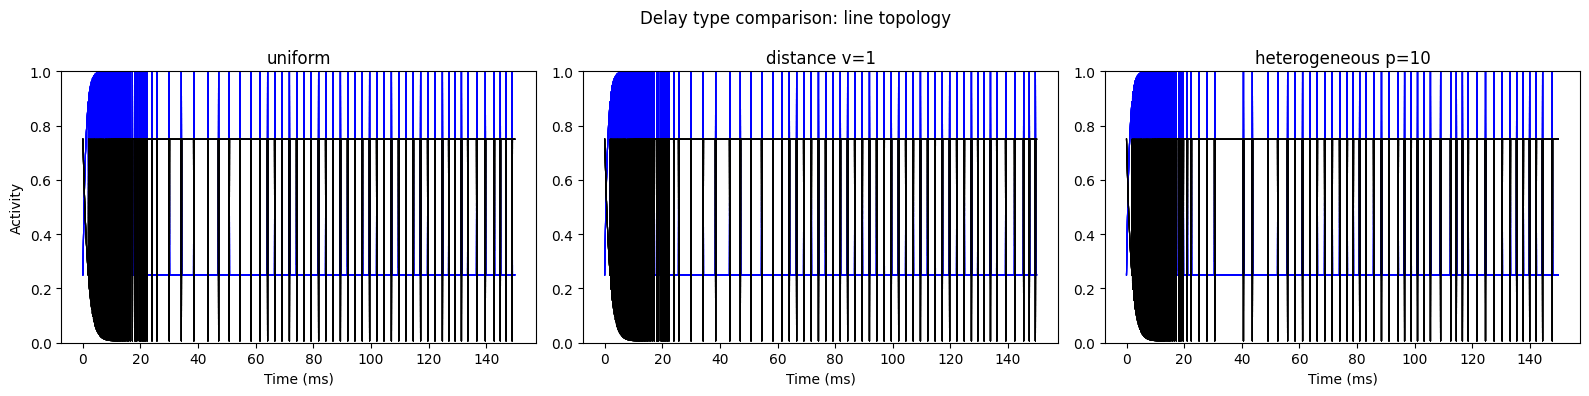

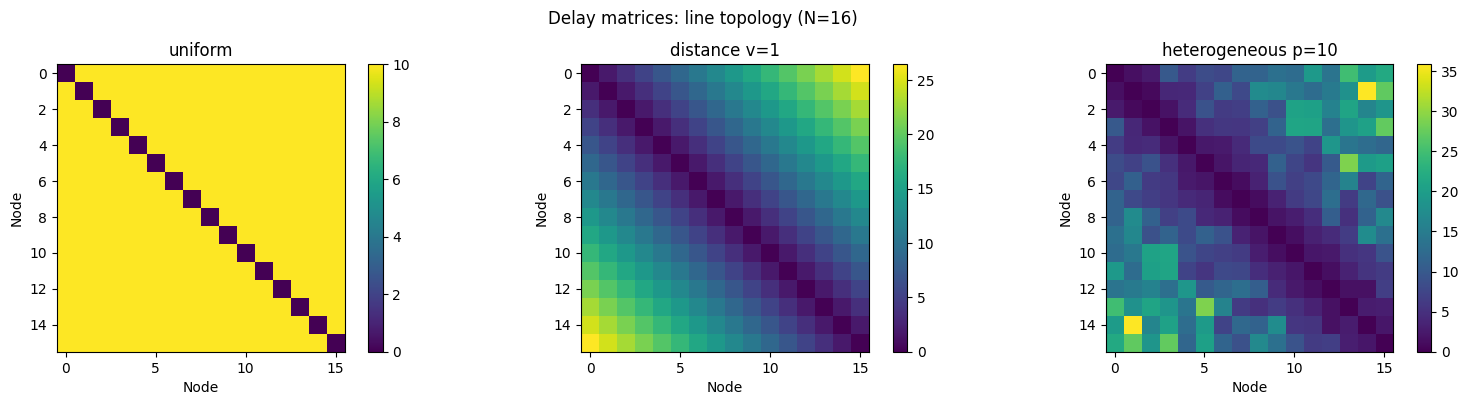

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Delay type comparison: line topology")

configs = [
    ('uniform', dict(mode='uniform', rho=10.0)),
    ('distance v=1', dict(mode='distance', v=1, target_mean_rho=10.0)),
    ('heterogeneous p=10', dict(mode='heterogeneous', vm=6.0, p=10, target_mean_rho=10.0, seed=42))
]

for i, (label, kwargs) in enumerate(configs):
    m = Metapopulation()
    m.load_config(CONFIG)
    m.create_network(params={'topology': 'line'})
    m.create_delay_matrix(**kwargs)
    m.initialise_model()
    m.run_simulation()
    
    t = m.model.time_array
    mask = t >= 0
    traj = m.model.trajectories
    
    axes[i].plot(t[mask], traj[0][:, mask].T, color='blue', alpha=0.5, linewidth=0.8)
    axes[i].plot(t[mask], traj[1][:, mask].T, color='black', alpha=0.5, linewidth=0.8)
    axes[i].set_title(label)
    axes[i].set_ylim(0, 1)
    axes[i].set_xlabel("Time (ms)")
    if i == 0:
        axes[i].set_ylabel("Activity")

plt.tight_layout()
plt.savefig("kavya_figures/regime_comparison_line.png", dpi=800)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Delay matrices: line topology (N=16)")

m_temp = Metapopulation()
m_temp.load_config(CONFIG)
m_temp.create_network(params={'topology': 'line'})

D_uniform = uniform_delay_matrix(m_temp.network, rho=10.0)
D_distance = distance_delay_matrix(m_temp.network, v=1, target_mean_rho=10.0)
D_hetero = heterogeneous_delay_matrix(m_temp.network, vm=6.0, p=10, target_mean_rho=10.0, seed=42)

matrices = [D_uniform, D_distance, D_hetero]
labels = ['uniform', 'distance v=1', 'heterogeneous p=10']

for i, (D, label) in enumerate(zip(matrices, labels)):
    im = axes[i].imshow(D, cmap='viridis')
    axes[i].set_title(label)
    axes[i].set_xlabel("Node")
    axes[i].set_ylabel("Node")
    plt.colorbar(im, ax=axes[i])

plt.tight_layout()
plt.savefig("kavya_figures/comparison_matrices_line.png", dpi=800)
plt.show()

Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10., 10., 10.,  0., 10., 10., 10., 10.,
        10., 10., 10.],
   

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10., 10., 10.,  0., 10., 10.,

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  8.44843762,  7.37628538, 18.8111508 ,  8.93149146,
         9.35424873,  7.10023862,  9.10896484,  8.03415769,  8.28215893,
         7.10221671,  9.8796496 ,  6.42970844, 10.71291616,  7.87679021,
         8.17046962],
       [ 8.44843762,  0.        ,  5.00448211, 11.02177975,  7.67961657,
         9.65327281, 12.28111913,  7.39211117, 13.9148267 , 11.61726621,
         8.9631764 ,  7.1168957 ,  7.53562417,  8.4896137 , 15.48737001,
        10.86620645],
       [ 7.37628538,  5.00448211,  0.        , 10.17820299, 12.46204656,
        16.90012786,  8.83328111,  7.46308946, 10.43049987,  7.14513311,
        14.46362817, 12.70199877,  8.89028631, 10.70903413,  7.65739084,
         8.06062931],
       [18.8111508 , 11.02177975, 10.17820299,  0.        , 10.48059688,
        14.04172664, 10.86263594,  8.00167

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.


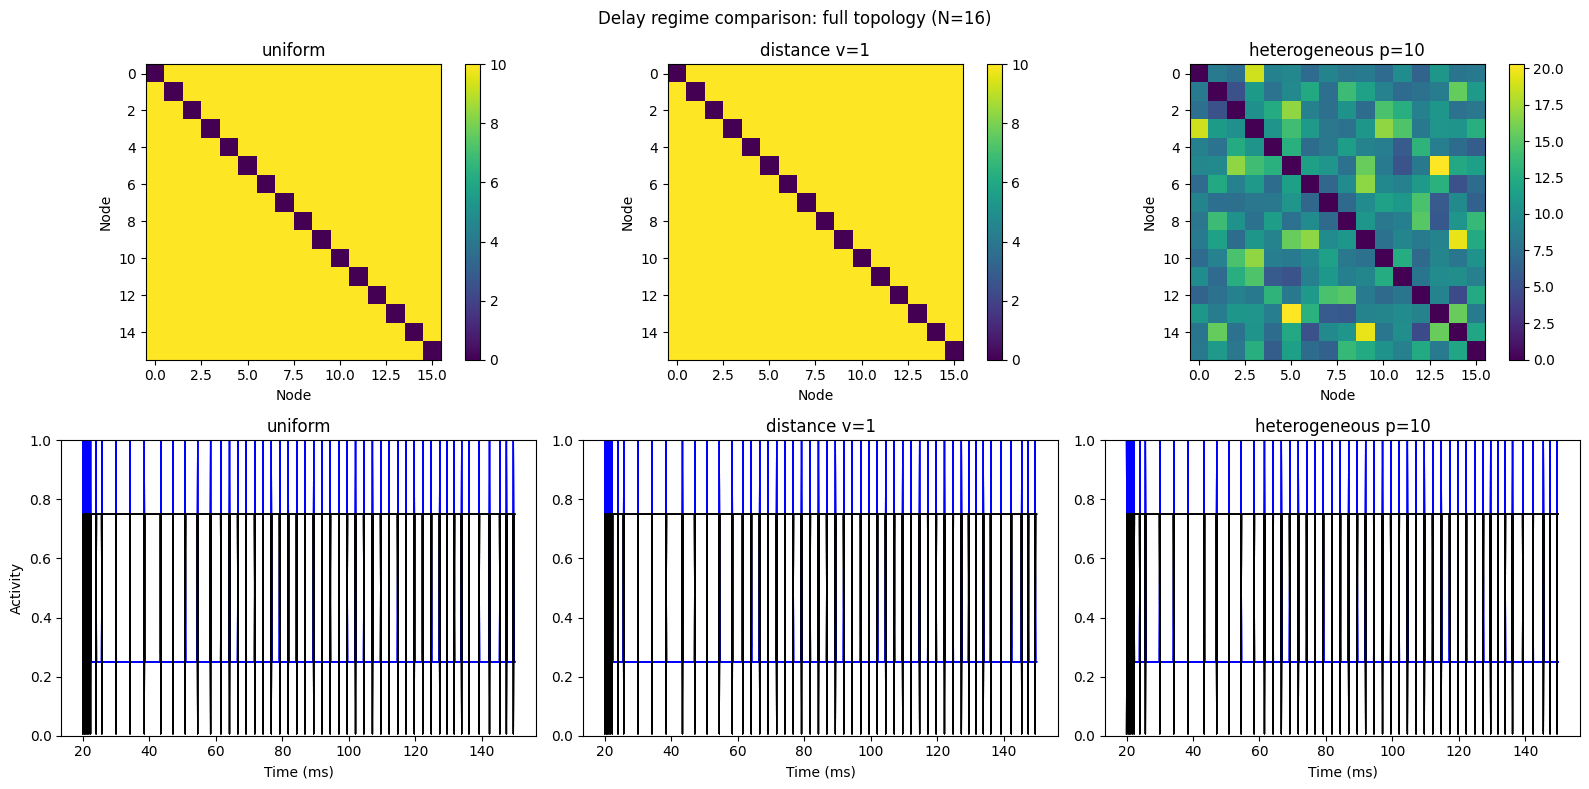

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Delay regime comparison: full topology (N=16)")

m_temp = Metapopulation()
m_temp.load_config(CONFIG)
m_temp.create_network(params={'topology': 'full'})

D_uniform = uniform_delay_matrix(m_temp.network, rho=10.0)
D_distance = distance_delay_matrix(m_temp.network, v=1, target_mean_rho=10.0)
D_hetero = heterogeneous_delay_matrix(m_temp.network, vm=6.0, p=10, target_mean_rho=10.0, seed=42)

matrices = [D_uniform, D_distance, D_hetero]
labels = ['uniform', 'distance v=1', 'heterogeneous p=10']

for i, (D, label) in enumerate(zip(matrices, labels)):
    im = axes[0, i].imshow(D, cmap='viridis')
    axes[0, i].set_title(label)
    axes[0, i].set_xlabel("Node")
    axes[0, i].set_ylabel("Node")
    plt.colorbar(im, ax=axes[0, i])

configs = [
    ('uniform', dict(mode='uniform', rho=10.0)),
    ('distance v=1', dict(mode='distance', v=1, target_mean_rho=10.0)),
    ('heterogeneous p=10', dict(mode='heterogeneous', vm=6.0, p=10, target_mean_rho=10.0, seed=42))
]

for i, (label, kwargs) in enumerate(configs):
    m = Metapopulation()
    m.load_config(CONFIG)
    m.create_network(params={'topology': 'full'})
    m.create_delay_matrix(**kwargs)
    m.initialise_model()
    m.run_simulation()
    
    t = m.model.time_array
    mask = t >= 20
    traj = m.model.trajectories
    
    axes[1, i].plot(t[mask], traj[0][:, mask].T, color='blue', alpha=0.5, linewidth=0.8)
    axes[1, i].plot(t[mask], traj[1][:, mask].T, color='black', alpha=0.5, linewidth=0.8)
    axes[1, i].set_title(label)
    axes[1, i].set_ylim(0, 1)
    axes[1, i].set_xlabel("Time (ms)")
    if i == 0:
        axes[1, i].set_ylabel("Activity")

plt.tight_layout()
plt.savefig("kavya_figures/comparison_full.png", dpi=800)
plt.show()

Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10., 10., 10.,  0., 10., 10., 10., 10.,
        10., 10., 10.],
   

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  5.55555556,  5.55555556,  5.55555556, 11.11111111,
        11.11111111, 11.11111111, 16.66666667, 16.66666667, 16.66666667,
        11.11111111, 11.11111111, 11.11111111,  5.55555556,  5.55555556,
         5.55555556],
       [ 5.55555556,  0.        ,  5.55555556,  5.55555556,  5.55555556,
        11.11111111, 11.11111111, 11.11111111, 16.66666667, 16.66666667,
        16.66666667, 11.11111111, 11.11111111, 11.11111111,  5.55555556,
         5.55555556],
       [ 5.55555556,  5.55555556,  0.        ,  5.55555556,  5.55555556,
         5.55555556, 11.11111111, 11.11111111, 11.11111111, 16.66666667,
        16.66666667, 16.66666667, 11.11111111, 11.11111111, 11.11111111,
         5.55555556],
       [ 5.55555556,  5.55555556,  5.55555556,  0.        ,  5.55555556,
         5.55555556,  5.55555556, 11.11111

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  4.66774488,  4.07538291, 10.39312318,  9.86926232,
        10.33640741,  7.84573527, 15.09805455, 13.31656814, 13.72762871,
         7.84792104, 10.91697327,  7.10480209,  5.91886475,  4.35191083,
         4.51416812],
       [ 4.66774488,  0.        ,  2.76496635,  6.08951126,  4.24297279,
        10.66682782, 13.57058749,  8.16825327, 23.06374173, 19.25554901,
        14.85641108,  7.86414126,  8.32683455,  9.38098917,  8.55674094,
         6.00355732],
       [ 4.07538291,  2.76496635,  0.        ,  5.62343679,  6.88525579,
         9.33728683,  9.76074028,  8.24668398, 11.52566062, 11.84301525,
        23.97337687, 21.05348671,  9.8237308 , 11.83343986,  8.46138624,
         4.45348156],
       [10.39312318,  6.08951126,  5.62343679,  0.        ,  5.79050881,
         7.75802587,  6.00158462,  8.84181

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.


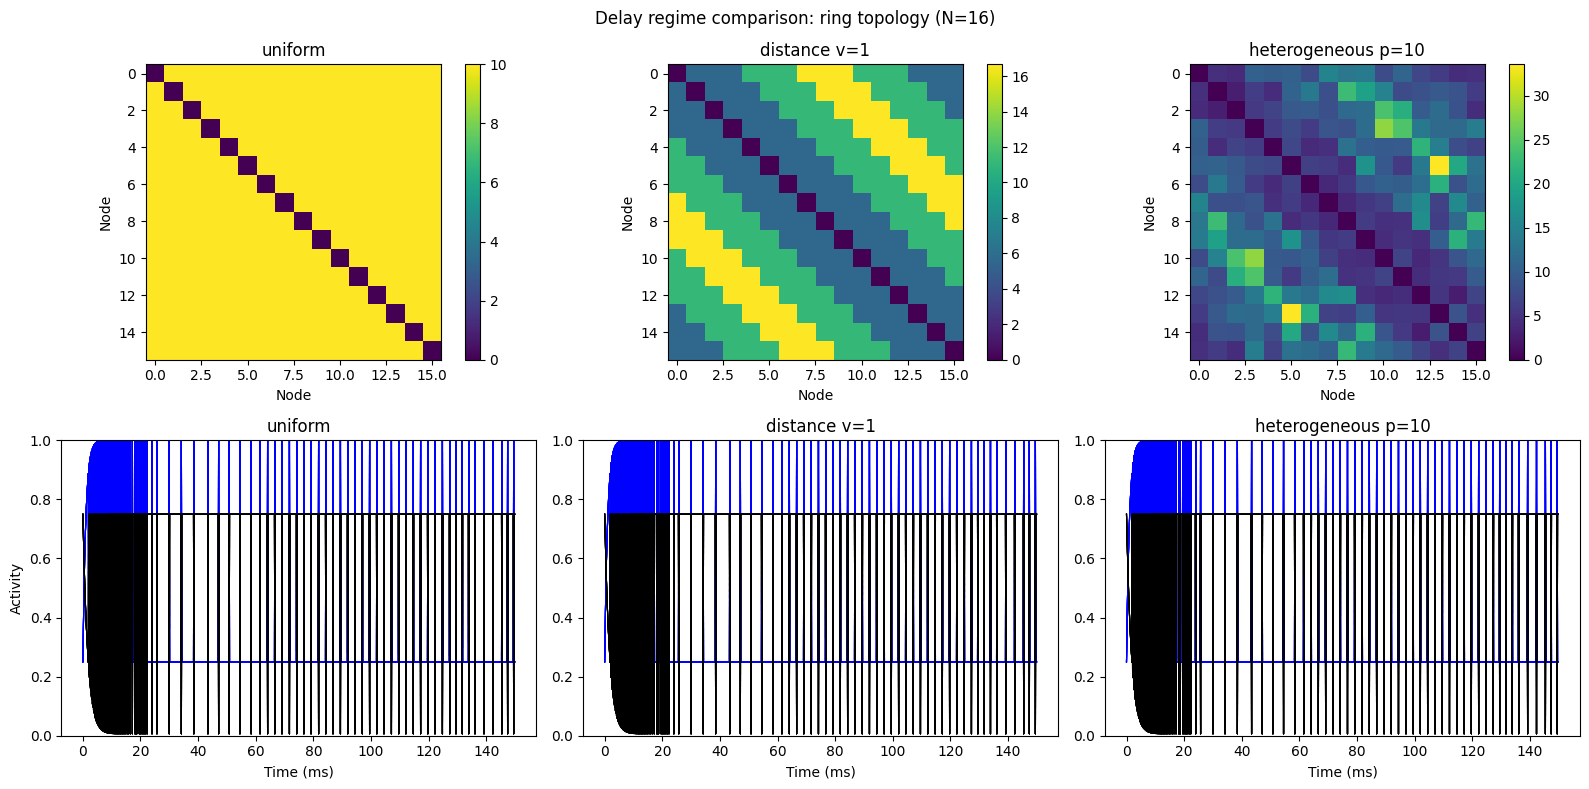

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Delay regime comparison: ring topology (N=16)")

m_temp = Metapopulation()
m_temp.load_config(CONFIG)
m_temp.create_network(params={'topology': 'ring'})

D_uniform = uniform_delay_matrix(m_temp.network, rho=10.0)
D_distance = distance_delay_matrix(m_temp.network, v=1, target_mean_rho=10.0)
D_hetero = heterogeneous_delay_matrix(m_temp.network, vm=6.0, p=10, target_mean_rho=10.0, seed=42)

matrices = [D_uniform, D_distance, D_hetero]
labels = ['uniform', 'distance v=1', 'heterogeneous p=10']

for i, (D, label) in enumerate(zip(matrices, labels)):
    im = axes[0, i].imshow(D, cmap='viridis')
    axes[0, i].set_title(label)
    axes[0, i].set_xlabel("Node")
    axes[0, i].set_ylabel("Node")
    plt.colorbar(im, ax=axes[0, i])

configs = [
    ('uniform', dict(mode='uniform', rho=10.0)),
    ('distance v=1', dict(mode='distance', v=1, target_mean_rho=10.0)),
    ('heterogeneous p=10', dict(mode='heterogeneous', vm=6.0, p=10, target_mean_rho=10.0, seed=42))
]

for i, (label, kwargs) in enumerate(configs):
    m = Metapopulation()
    m.load_config(CONFIG)
    m.create_network(params={'topology': 'ring'})
    m.create_delay_matrix(**kwargs)
    m.initialise_model()
    m.run_simulation()
    
    t = m.model.time_array
    mask = t >= 20 & (t < 80)
    traj = m.model.trajectories
    
    axes[1, i].plot(t[mask], traj[0][:, mask].T, color='blue', alpha=0.5, linewidth=0.8)
    axes[1, i].plot(t[mask], traj[1][:, mask].T, color='black', alpha=0.5, linewidth=0.8)
    axes[1, i].set_title(label)
    axes[1, i].set_ylim(0, 1)
    axes[1, i].set_xlabel("Time (ms)")
    if i == 0:
        axes[1, i].set_ylabel("Activity")

plt.tight_layout()
plt.savefig("kavya_figures/comparison_ring.png", dpi=800)
plt.show()

Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10., 10., 10.,  0., 10., 10., 10., 10.,
        10., 10., 10.],
   

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.  ,  3.75,  7.5 , 11.25,  3.75,  7.5 , 11.25, 15.  ,  7.5 ,
        11.25, 15.  , 18.75, 11.25, 15.  , 18.75, 22.5 ],
       [ 3.75,  0.  ,  3.75,  7.5 ,  7.5 ,  3.75,  7.5 , 11.25, 11.25,
         7.5 , 11.25, 15.  , 15.  , 11.25, 15.  , 18.75],
       [ 7.5 ,  3.75,  0.  ,  3.75, 11.25,  7.5 ,  3.75,  7.5 , 15.  ,
        11.25,  7.5 , 11.25, 18.75, 15.  , 11.25, 15.  ],
       [11.25,  7.5 ,  3.75,  0.  , 15.  , 11.25,  7.5 ,  3.75, 18.75,
        15.  , 11.25,  7.5 , 22.5 , 18.75, 15.  , 11.25],
       [ 3.75,  7.5 , 11.25, 15.  ,  0.  ,  3.75,  7.5 , 11.25,  3.75,
         7.5 , 11.25, 15.  ,  7.5 , 11.25, 15.  , 18.75],
       [ 7.5 ,  3.75,  7.5 , 11.25,  3.75,  0.  ,  3.75,  7.5 ,  7.5 ,
         3.75,  7.5 , 11.25, 11.25,  7.5 , 11.25, 15.  ],
       [11.25,  7.5 ,  3.75,  7.5 ,  7.5 ,  3.75,  0.  ,  3.75, 

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  3.22063044,  5.62383017, 21.51300659,  3.40477547,
         7.1318697 ,  8.12004975, 13.88972054,  6.12540541,  9.47172991,
        10.82974927, 18.83111505,  7.35321095, 16.33549084, 15.0135631 ,
        18.68799722],
       [ 3.22063044,  0.        ,  1.90775953,  8.40322931,  5.85509604,
         3.67992587,  9.36337529,  8.45384411, 15.91342081,  8.85724031,
        10.25056229, 10.85213238, 11.49062661,  9.70898152, 23.61577249,
        20.71154262],
       [ 5.62383017,  1.90775953,  0.        ,  3.8800346 , 14.25197707,
        12.8850016 ,  3.36733669,  5.69001136, 15.90485097,  8.17139246,
        11.02736462, 14.52639374, 16.94533826, 16.32957135,  8.75722604,
        12.29117582],
       [21.51300659,  8.40322931,  3.8800346 ,  0.        , 15.98124093,
        16.05854746,  8.28189483,  3.05031

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.


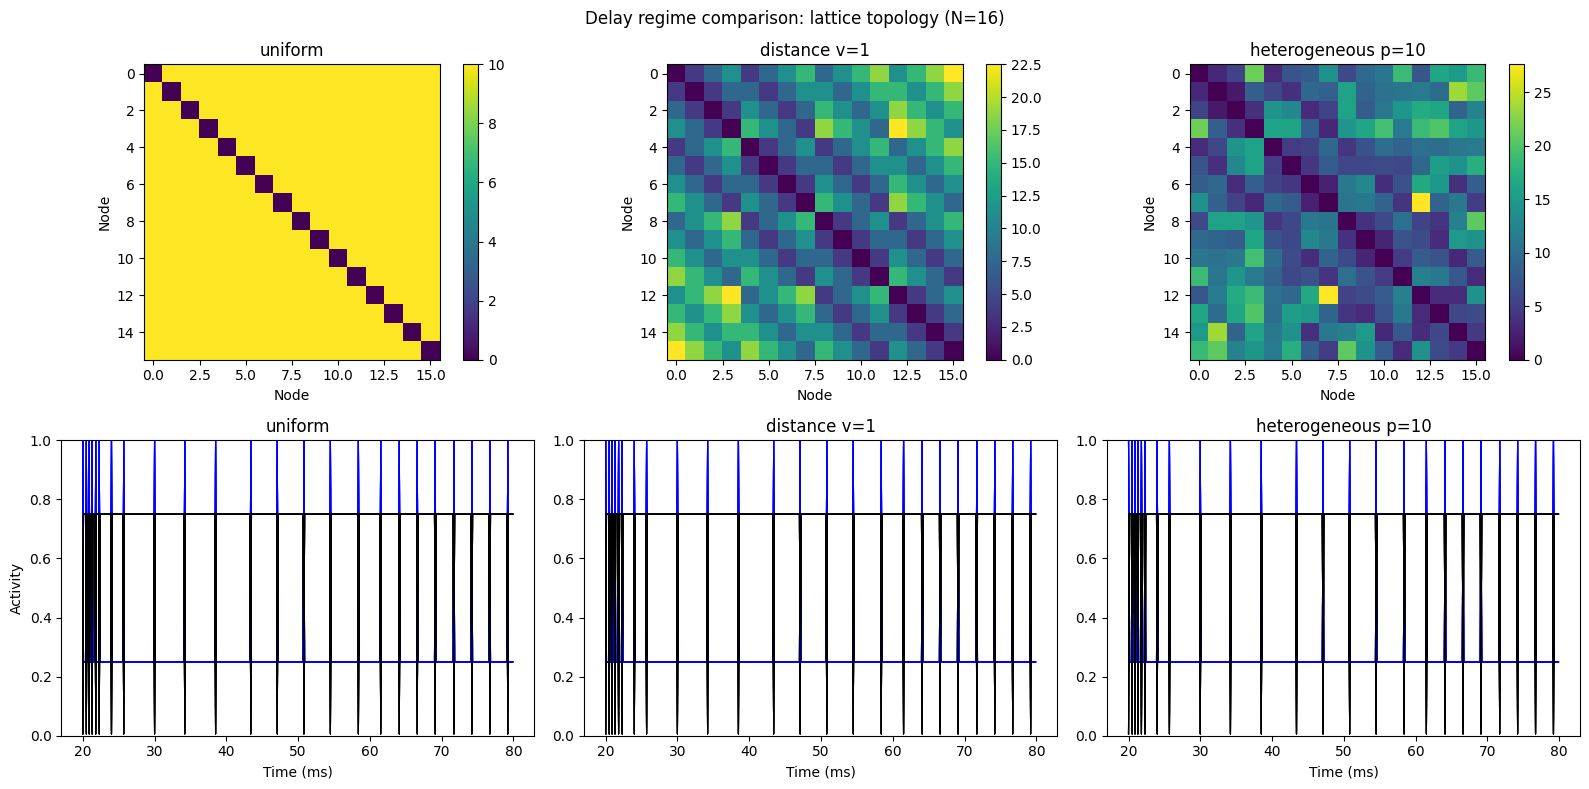

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Delay regime comparison: lattice topology (N=16)")

m_temp = Metapopulation()
m_temp.load_config(CONFIG)
m_temp.create_network(params={'topology': 'lattice'})

D_uniform = uniform_delay_matrix(m_temp.network, rho=10.0)
D_distance = distance_delay_matrix(m_temp.network, v=1, target_mean_rho=10.0)
D_hetero = heterogeneous_delay_matrix(m_temp.network, vm=6.0, p=10, target_mean_rho=10.0, seed=42)

matrices = [D_uniform, D_distance, D_hetero]
labels = ['uniform', 'distance v=1', 'heterogeneous p=10']

for i, (D, label) in enumerate(zip(matrices, labels)):
    im = axes[0, i].imshow(D, cmap='viridis')
    axes[0, i].set_title(label)
    axes[0, i].set_xlabel("Node")
    axes[0, i].set_ylabel("Node")
    plt.colorbar(im, ax=axes[0, i])

configs = [
    ('uniform', dict(mode='uniform', rho=10.0)),
    ('distance v=1', dict(mode='distance', v=1, target_mean_rho=10.0)),
    ('heterogeneous p=10', dict(mode='heterogeneous', vm=6.0, p=10, target_mean_rho=10.0, seed=42))
]

for i, (label, kwargs) in enumerate(configs):
    m = Metapopulation()
    m.load_config(CONFIG)
    m.create_network(params={'topology': 'lattice'})
    m.create_delay_matrix(**kwargs)
    m.initialise_model()
    m.run_simulation()
    
    t = m.model.time_array
    mask = (t >= 20) & (t < 80)
    traj = m.model.trajectories
    
    axes[1, i].plot(t[mask], traj[0][:, mask].T, color='blue', alpha=0.5, linewidth=0.8)
    axes[1, i].plot(t[mask], traj[1][:, mask].T, color='black', alpha=0.5, linewidth=0.8)
    axes[1, i].set_title(label)
    axes[1, i].set_ylim(0, 1)
    axes[1, i].set_xlabel("Time (ms)")
    if i == 0:
        axes[1, i].set_ylabel("Activity")

plt.tight_layout()
plt.savefig("kavya_figures/comparison_lattice.png", dpi=800)
plt.show()

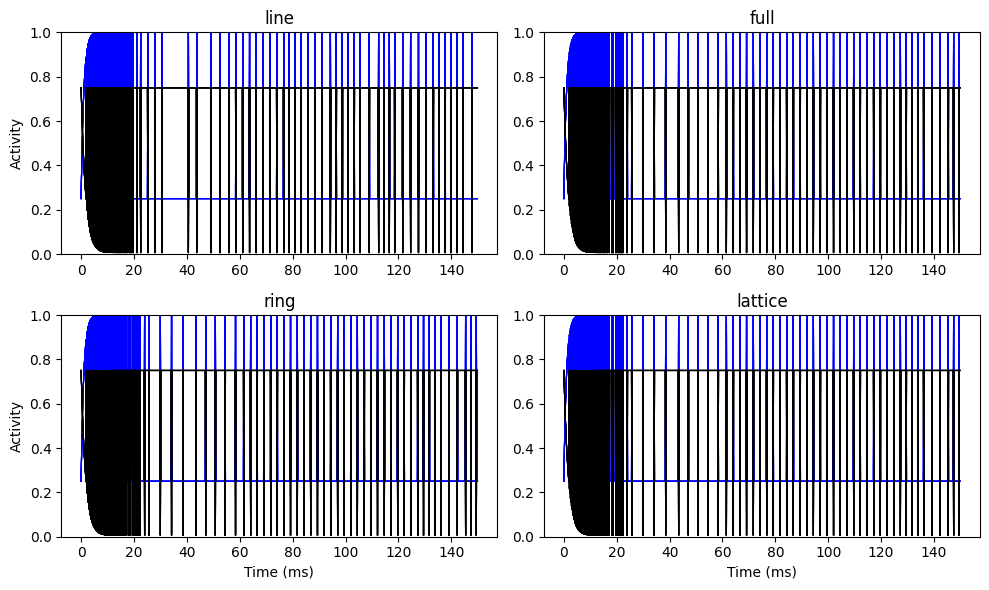

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
for i, topology in enumerate(TOPOLOGIES):
    row = i // 2
    col = i % 2
    r = results[(topology, 'heterogeneous')]
    ax = axes[row, col]
    t = r['time']
    mask = t >= 0
    ax.plot(t[mask], r['trajectories'][0][:, mask].T, color='blue', alpha=0.5, linewidth=0.8)
    ax.plot(t[mask], r['trajectories'][1][:, mask].T, color='black', alpha=0.5, linewidth=0.8)
    ax.set_title(topology)
    ax.set_ylim(0, 1)
    if row == 1:
        ax.set_xlabel("Time (ms)")
    if col == 0:
        ax.set_ylabel("Activity")

plt.tight_layout()
plt.savefig("kavya_figures/heterogeneous_delays_trajectories.png", dpi=800)
plt.show()

Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10., 10.,  0., 10., 10., 10., 10., 10.,
        10., 10., 10.],
       [10., 10., 10., 10., 10., 10., 10., 10.,  0., 10., 10., 10., 10.,
        10., 10., 10.],
   

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  1.76470588,  3.52941176,  5.29411765,  7.05882353,
         8.82352941, 10.58823529, 12.35294118, 14.11764706, 15.88235294,
        17.64705882, 19.41176471, 21.17647059, 22.94117647, 24.70588235,
        26.47058824],
       [ 1.76470588,  0.        ,  1.76470588,  3.52941176,  5.29411765,
         7.05882353,  8.82352941, 10.58823529, 12.35294118, 14.11764706,
        15.88235294, 17.64705882, 19.41176471, 21.17647059, 22.94117647,
        24.70588235],
       [ 3.52941176,  1.76470588,  0.        ,  1.76470588,  3.52941176,
         5.29411765,  7.05882353,  8.82352941, 10.58823529, 12.35294118,
        14.11764706, 15.88235294, 17.64705882, 19.41176471, 21.17647059,
        22.94117647],
       [ 5.29411765,  3.52941176,  1.76470588,  0.        ,  1.76470588,
         3.52941176,  5.29411765,  7.05882

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.
Model parameters:
{'mode': 'wilson_cowan', 'c_ee': 1, 'c_ei': -1, 'c_ie': 1, 'c_ii': -1, 'tau_1': 1.0, 'tau_2': 1.4, 'rho': array([[ 0.        ,  1.50534914,  2.62862445, 10.05535613,  6.36568019,
         8.33373631,  7.59075601, 11.36129673, 11.45225937, 13.28149328,
        12.65478459, 19.36399956, 13.74780498, 24.81486379, 19.64889588,
        21.83730882],
       [ 1.50534914,  0.        ,  0.89170249,  3.92773846,  4.10508003,
         6.88011042, 10.94129646,  7.90279247, 17.35548198, 16.55978773,
        14.37359124, 12.68093972, 14.76973668, 18.15223111, 35.87417015,
        27.1060868 ],
       [ 2.62862445,  0.89170249,  0.        ,  1.81356007,  4.44099416,
         9.0338335 ,  6.2956834 ,  6.64889522, 11.15108714,  8.91187736,
        20.61712351, 20.36926755, 15.84078081, 20.98958369, 16.37279777,
        18.67123902],
       [10.05535613,  3.92773846,  1.81356007,  0.        ,  1.86744085,
         5.0039314 ,  5.80653859,  5.70297

ld: warning: duplicate -rpath '/Users/kavya/anaconda3/lib' ignored


Using default integration parameters.


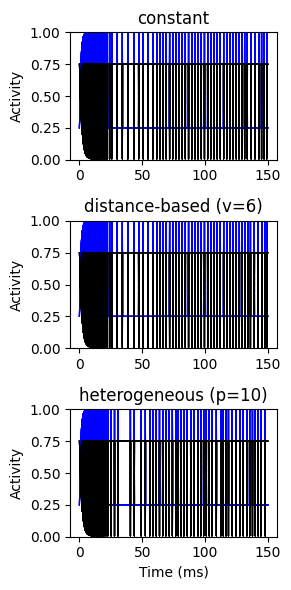

In [26]:
fig, axes = plt.subplots(3, 1, figsize=(3, 6))

configs = [
    ('constant', dict(mode='uniform', rho=10.0)),
    ('distance-based (v=6)', dict(mode='distance', v=6, target_mean_rho=10.0)),
    ('heterogeneous (p=10)', dict(mode='heterogeneous', vm=6.0, p=10, target_mean_rho=10.0, seed=42))
]

for i, (label, kwargs) in enumerate(configs):
    m = Metapopulation()
    m.load_config(CONFIG)
    m.create_network(params={'topology': 'line'})
    m.create_delay_matrix(**kwargs)
    m.initialise_model()
    m.run_simulation()
    
    t = m.model.time_array
    mask = t >= 0
    traj = m.model.trajectories
    
    axes[i].plot(t[mask], traj[0][:, mask].T, color='blue', alpha=0.5, linewidth=0.8)
    axes[i].plot(t[mask], traj[1][:, mask].T, color='black', alpha=0.5, linewidth=0.8)
    axes[i].set_title(label)
    axes[i].set_ylim(0, 1)
    axes[i].set_ylabel("Activity")
    if i == 2:
        axes[i].set_xlabel("Time (ms)")

plt.tight_layout()
plt.savefig("kavya_figures/regime_comparison_line.png", dpi=800)
plt.show()